# EDA 01 — Central Bank Gold Reserves

**Goal:** Explore the distribution, trend, and concentration of gold holdings across central banks globally.

Data source: WGC / IMF IFS via `data/curated/master_panel_nlp.csv`

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

BASE_DIR = Path("..") 
df = pd.read_csv(BASE_DIR / "data/curated/gold_features.csv")
print(df.shape)
df.head()

(4283, 13)


,country,country_code,year,reserves_excl_gold_usd,total_reserves_usd,gold_value_usd,gold_share_pct,gold_yoy_change_usd,gold_yoy_change_pct,gold_share_yoy_change,is_accumulating,accumulation_streak,gold_rank
0,Aruba,ABW,2000,2.080100e+08,2.354550e+08,27445000.0,11.66,NaN,NaN,NaN,0,0,79
1,Aruba,ABW,2001,2.937106e+08,3.213606e+08,27650000.0,8.60,205000.0,0.75,-3.06,1,1,80
2,Aruba,ABW,2002,3.397279e+08,3.740029e+08,34275000.0,9.16,6625000.0,23.96,0.56,1,2,79
3,Aruba,ABW,2003,2.952207e+08,3.369457e+08,41725000.0,12.38,7450000.0,21.74,3.22,1,3,75
4,Aruba,ABW,2004,2.954240e+08,3.392240e+08,43800000.0,12.91,2075000.0,4.97,0.53,1,4,75


## 2. Top 10 Gold Holders by Value (Latest Year)

Ranks countries by total gold value in USD to identify the world's dominant gold holders.

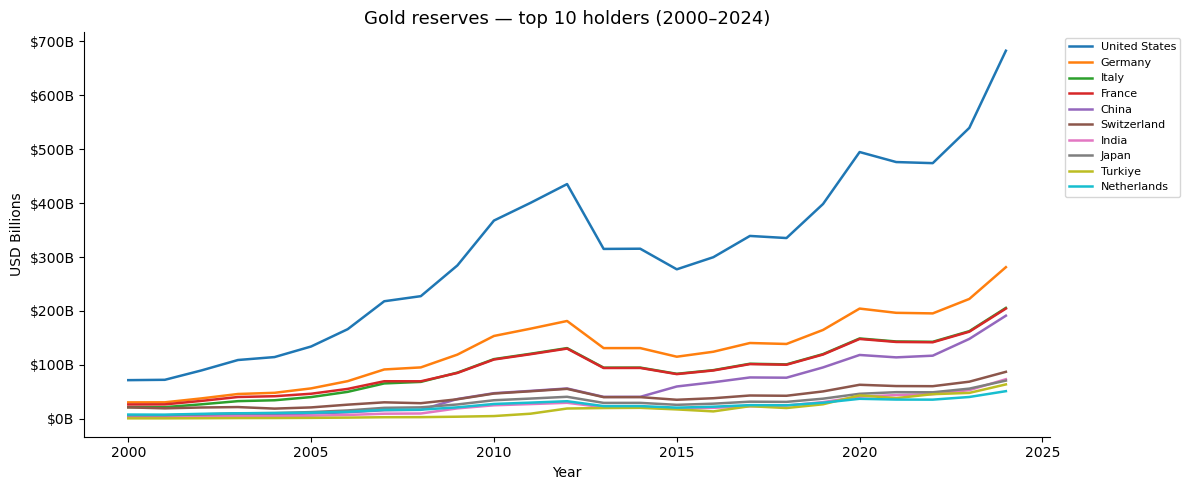

In [2]:
top10 = (
    df[df["year"] == 2024]
    .nlargest(10, "gold_value_usd")["country_code"].tolist()
)

fig, ax = plt.subplots(figsize=(12, 5))
for code in top10:
    subset = df[df["country_code"] == code]
    ax.plot(subset["year"], subset["gold_value_usd"] / 1e9, 
            label=subset["country"].iloc[0], linewidth=1.8)

ax.set_title("Gold reserves — top 10 holders (2000–2024)", fontsize=13)
ax.set_ylabel("USD Billions")
ax.set_xlabel("Year")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}B"))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
sns.despine()
plt.tight_layout()
plt.savefig(BASE_DIR / "docs/top10_gold_holders.png", dpi=150)
plt.show()

## 3. Gold Accumulation Trends — Key Countries

Tracks tonnage held by major central banks over time. Highlights structural buyers vs. sellers.

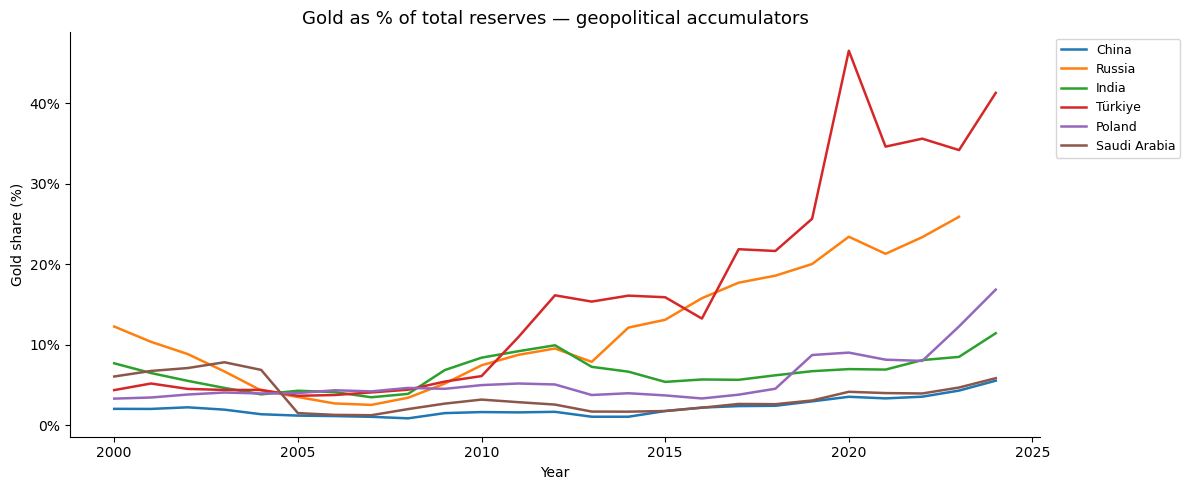

In [3]:
focus = ["CHN", "RUS", "IND", "TUR", "POL", "SAU"]
labels = {"CHN": "China", "RUS": "Russia", "IND": "India",
          "TUR": "Türkiye", "POL": "Poland", "SAU": "Saudi Arabia"}

fig, ax = plt.subplots(figsize=(12, 5))
for code in focus:
    subset = df[df["country_code"] == code]
    if subset.empty:
        continue
    ax.plot(subset["year"], subset["gold_share_pct"],
            label=labels.get(code, code), linewidth=1.8)

ax.set_title("Gold as % of total reserves — geopolitical accumulators", fontsize=13)
ax.set_ylabel("Gold share (%)")
ax.set_xlabel("Year")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(BASE_DIR / "docs/geo_accumulators_share.png", dpi=150)
plt.show()

## 4. Gold Share of Total Reserves — Heatmap

Shows gold as a percentage of total foreign reserves. A rising share signals deliberate de-dollarization.

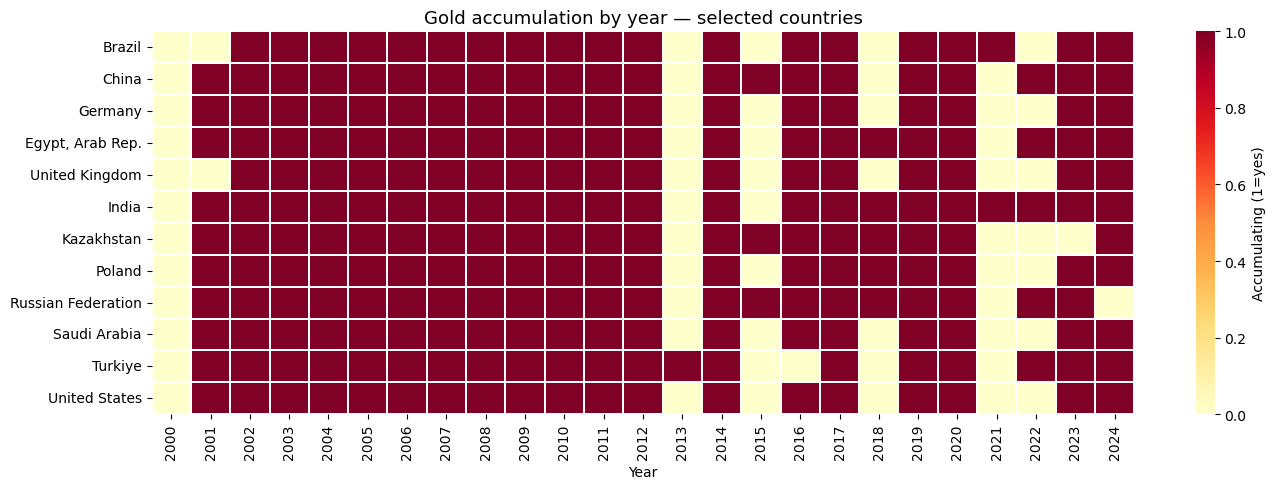

In [4]:
countries_of_interest = [
    "CHN","RUS","IND","TUR","POL","SAU","USA","DEU","GBR","BRA","EGY","KAZ"
]
name_map = df.set_index("country_code")["country"].to_dict()

heat = (
    df[df["country_code"].isin(countries_of_interest)]
    .pivot_table(index="country_code", columns="year", values="is_accumulating")
    .fillna(0)
)
heat.index = [name_map.get(c, c) for c in heat.index]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat, cmap="YlOrRd", linewidths=0.3, linecolor="white",
            cbar_kws={"label": "Accumulating (1=yes)"}, ax=ax)
ax.set_title("Gold accumulation by year — selected countries", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(BASE_DIR / "docs/accumulation_heatmap.png", dpi=150)
plt.show()

## 5. Accumulation Streak Analysis

Countries ranked by consecutive years of uninterrupted gold buying — the most reliable predictor of continued accumulation.